In [3]:
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
#df2=pd.read_csv("/content/drive/MyDrive/EDA 1.csv")
#df3=pd.read_csv("/content/drive/MyDrive/xeek_train_subset.csv")
#f=pd.read_csv("/content/drive/MyDrive/pakistan_intellectual_capital (1).csv")
#df4=pd.read_csv("/content/drive/MyDrive/Airbnb.csv")
#df6=pd.read_csv("/content/drive/MyDrive/pakistan_intellectual_capital (1).csv")
#df7=pd.read_csv("/content/drive/MyDrive/application_data.csv")
df=pd.read_csv("/content/drive/MyDrive/Netflix_dataset.csv")

In [6]:
#Step 1: Understanding the Dataset
#1. What is the shape of the dataset (number of rows and columns)?
#2. What are the first few entries in the dataset?
#3. How many unique values are there in each column?
#4. What are the data types of each column?
#5. How many missing values exist in each column?
#6 numeric - normal mean, skewed median
# when mean and median are close then we impute with the mean
# timeseries data ffill backward fill
#7 categorical - most frequently occuring value
#8 categorical - create new category
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [5]:
#Step 1: Understanding the Dataset
#1. What is the shape of the dataset (number of rows and columns)?
df.shape

(8807, 12)

In [31]:
#Step 1: Understanding the Dataset
#2. What are the first few entries in the dataset?
df.head(n=20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [30]:
#Step 1: Understanding the Dataset
#3. How many unique values are there in each column?
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4529
cast,7693
country,749
date_added,1775
release_year,74
rating,17
duration,220


In [12]:
#Step 1: Understanding the Dataset
#4. What are the data types of each column?
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [15]:
#Step 1: Understanding the Dataset
#5. How many missing values exist in each column?
missing = df.isnull().sum()
percent_missing = (df.isnull().mean() * 100).round(2)
percent_missing

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
#Step 2: Data Cleaning and Preprocessing
#6. How can missing values be handled in different columns?
#7. Are there any incorrect or inconsistent values in the dataset?
#8. What transformations are needed to convert data into the correct format?
#9. How can we convert the date_added column into a proper datetime format?
#10. What are the unique content types (Movie/TV Show) in the dataset?

#Replace with most commonly occuring value
#Replace with Unknown
#Convert negative to positive if it does not make sense
#Take absolute
#take mod

In [29]:
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()

,0
rating,4
duration,3


In [36]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [37]:
df['duration'].value_counts()

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
...,...
228 min,1
18 min,1
205 min,1


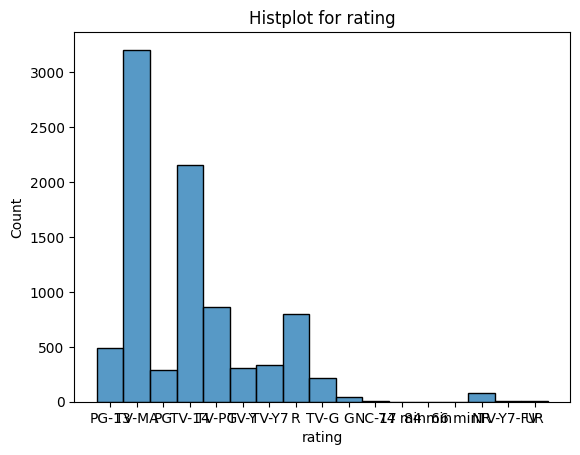

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['rating'], binwidth = 150000)
plt.title('Histplot for rating')
plt.show()

In [7]:
#6. How can missing values be handled in different columns?
#unique_values = df['director'].unique()
#unique_values
#Impute empty values for Director, Cast and Country with Unknown
df['director'].value_counts()

#Fill the empty values in the Director, Cast and Country columns with Unknown
df['director'].fillna(value = 'Unknown', inplace = True)
df['cast'].fillna(value = 'Unknown', inplace = True)
df['country'].fillna(value = 'Unknown', inplace = True)

<ipython-input-7-33cbe9e918ce>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna(value = 'Unknown', inplace = True)
<ipython-input-7-33cbe9e918ce>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [6]:
df[df["director"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [21]:
df[df["cast"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
...,...,...,...,...,...,...,...,...,...,...,...,...
8746,s8747,Movie,Winnie,Pascale Lamche,NaN,"France, Netherlands, South Africa, Finland","February 26, 2018",2017,TV-14,85 min,"Documentaries, International Movies",Winnie Mandela speaks about her extraordinary ...
8755,s8756,TV Show,Women Behind Bars,NaN,NaN,United States,"November 1, 2016",2010,TV-14,3 Seasons,"Crime TV Shows, Docuseries",This reality series recounts true stories of w...
8756,s8757,Movie,Woodstock,Barak Goodman,NaN,United States,"August 13, 2019",2019,TV-MA,97 min,"Documentaries, Music & Musicals",For the 50th anniversary of the legendary Wood...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


In [26]:
df[df["date_added"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [8]:
#Impute empty values for date_added as 01-01 of that release year
temp_year_month=df['release_year']
#df['date_added'].fillna(value = df['release_year'].concat("-01-01"), inplace = True)
#df['date_added'] = df['release_year'] + '-' + df['col2']
temp_year_year=df['release_year'].astype(str)+"-01-01"
temp_year_year
df['date_added'].fillna(value = df['release_year'].astype(str)+"-01-01", inplace = True)

<ipython-input-8-4226e3e416e3>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(value = df['release_year'].astype(str)+"-01-01", inplace = True)


In [9]:
#7. Are there any incorrect or inconsistent values in the dataset?
#8. What transformations are needed to convert data into the correct format?
#df2_temp=df
#df2_temp
#pd.to_datetime(df2_temp['date_added'])
#pd.to_datetime(df2_temp["date_added"].dt.strftime('%Y-%m'))
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [10]:
#The column "rating" seems to have the value for duration in the following 3 show ids:
#s5542
#s5795
#s5814
#df[df["date_added"].isnull()]
#df['duration'].fillna(value = df['rating'], inplace = True)


#df[df['show_id']=='s5542']
#The value in the column rating is actually the duration
#replace the value in the column duration with the value in the column rating
#replace the value in the column rating in these rows as null
df['duration'].fillna(value = df['rating'], inplace = True)

<ipython-input-10-a2a21ab8cbaf>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration'].fillna(value = df['rating'], inplace = True)


In [11]:
#use loc to find the rows where the value of rating needs to be updated
df.loc[(df['show_id']=='s5542') | (df['show_id']=='s5795') | (df['show_id']=='s5814')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,66 min,Movies,The comic puts his trademark hilarious/thought...


In [12]:
df.loc[df['show_id'] == 's5542', 'rating'] = ''
df.loc[df['show_id'] == 's5795', 'rating'] = ''
df.loc[df['show_id'] == 's5814', 'rating'] = ''

In [24]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [25]:
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [40]:
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [51]:
#9. How can we convert the date_added column into a proper datetime format?
#10. What are the unique content types (Movie/TV Show) in the dataset? A

#date_string_with_time = "2025-03-23 10:30:00"
#    date_object_with_time = datetime.strptime(date_string_with_time, "%Y-%m-%d %H:%M:%S")
#    print(date_object_with_time)
#    # Output: 2025-03-23 10:30:00
#df['director'].fillna(value = 'Unknown', inplace = True)

#str_date_added=df['date_added']
#str_date_added_correct=datetime.strptime(str_date_added, "%Y-%m-%d %H:%M:%S")
#str_date_added_correct

#df['date_added_correct'] = pd.to_datetime(df['date_added'], format='%Y-%m-%d')

from datetime import datetime

#date_string = "September 25, 2021"
#date_object = datetime.strptime(date_string, "%B %d, %Y")

#date_string = df['date_added'][0]
#date_object = datetime.strptime(date_string, "%B %d, %Y")
#df['date_added_new'][0]=date_object

#print(df['date_added_new'][0])
# Output: 2021-09-25 00:00:00

import pandas as pd

# Sample DataFrame
data = df['date_added']
#{'date_str': ['2025-03-20', '2025-03-21', '2025-03-22']}
df = pd.DataFrame(data)

# Convert the 'date_str' column to datetime
df['date_datetime'] = pd.to_datetime(df['date_added'])

# Print the DataFrame with the new datetime column
print(df)

ValueError: time data "2013-01-01" doesn't match format "%B %d, %Y", at position 1439. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [23]:
#9. How can we convert the date_added column into a proper datetime format?
#10. What are the unique content types (Movie/TV Show) in the dataset? A
df['type'].unique(),


array(['Movie', 'TV Show'], dtype=object)

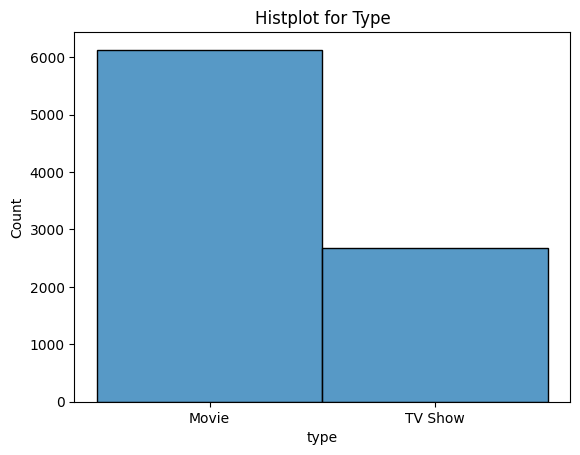

In [24]:
#🔹 Step 3: Exploring the Dataset Using Pandas
#11. What is the distribution of content (Movies vs. TV Shows) on Netflix?
#12. What are the different ratings available on Netflix, and how are they distributed?
#13. How many unique genres are available in the dataset?
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['type'], binwidth = 150000)
plt.title('Histplot for Type')
plt.show()


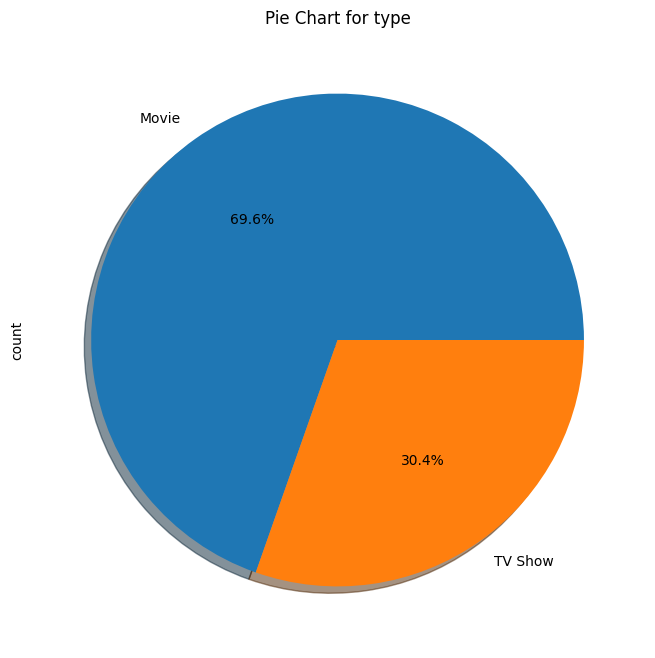

In [35]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, figsize=(8,8))
plt.title('Pie Chart for type')
plt.show()

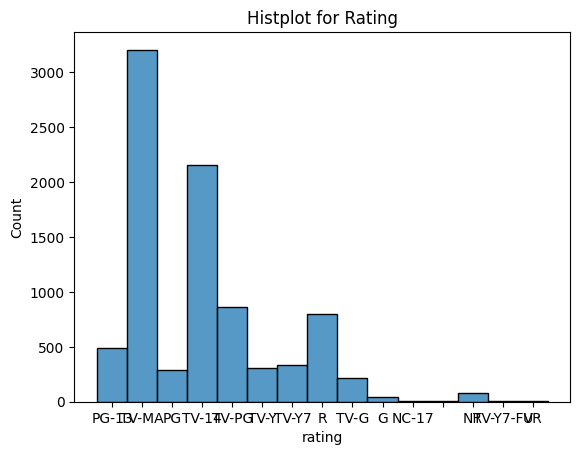

In [31]:
#12. What are the different ratings available on Netflix, and how are they distributed?
#13. How many unique genres are available in the dataset?
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['rating'], binwidth = 150000)
plt.title('Histplot for Rating')
plt.show()

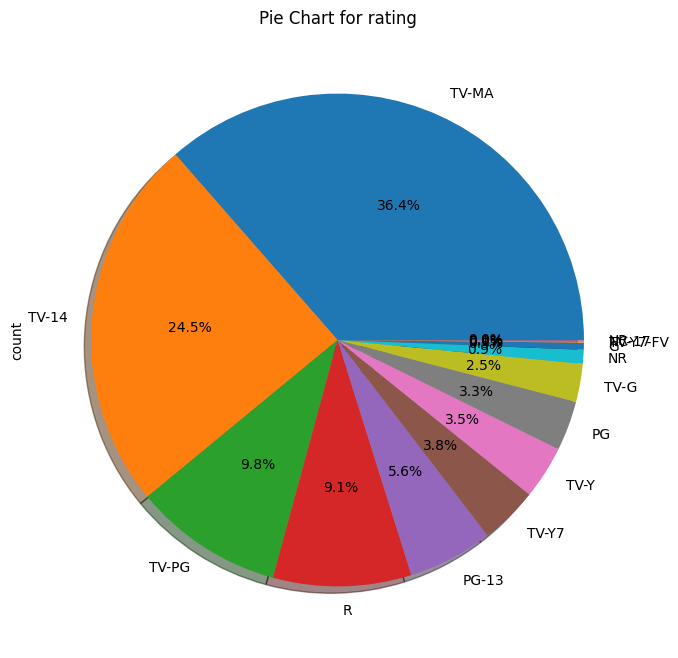

In [36]:
df['rating'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, figsize=(8,8))
plt.title('Pie Chart for rating')
plt.show()

In [40]:
#13. How many unique genres are available in the dataset?
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['rating'], binwidth = 150000)
plt.title('Histplot for Rating')
plt.show()

df['listed_in'].nunique()

514

In [43]:
df['listed_in'].unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

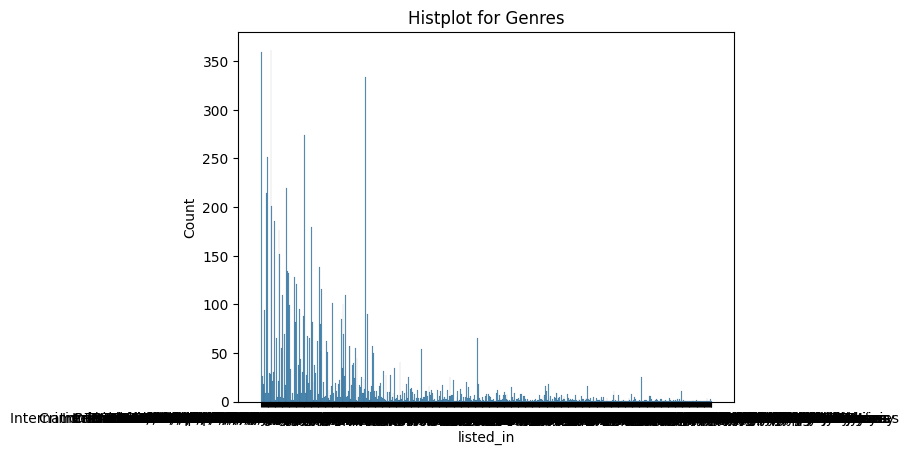

In [41]:
#13. How many unique genres are available in the dataset?
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['listed_in'], binwidth = 150000)
plt.title('Histplot for Genres')
plt.show()

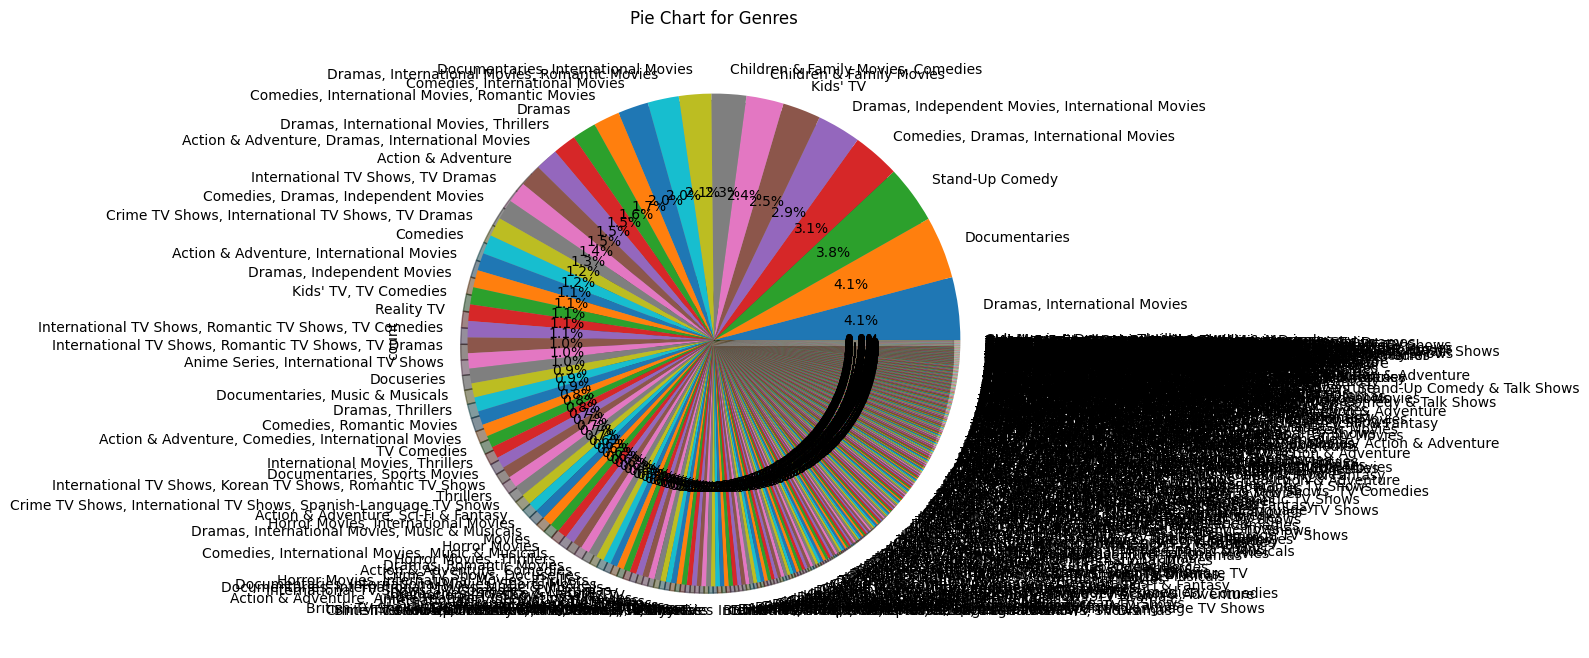

In [42]:
#13. How many unique genres are available in the dataset?
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
df['listed_in'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, figsize=(8,8))
plt.title('Pie Chart for Genres')
plt.show()

In [ ]:
#14. How many movies and TV shows have been directed by each director?
#15. How many shows/movies were added to Netflix each year?
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x = df['rating'], binwidth = 150000)
plt.title('Histplot for Rating')
plt.show()

df['listed_in'].nunique()

                          Missing Values  Percentage (%)
COMMONAREA_AVG                    214865           69.87
COMMONAREA_MODE                   214865           69.87
COMMONAREA_MEDI                   214865           69.87
NONLIVINGAPARTMENTS_MEDI          213514           69.43
NONLIVINGAPARTMENTS_MODE          213514           69.43
...                                  ...             ...
FLAG_DOCUMENT_16                       0            0.00
FLAG_DOCUMENT_15                       0            0.00
FLAG_DOCUMENT_14                       0            0.00
FLAG_DOCUMENT_20                       0            0.00
FLAG_DOCUMENT_21                       0            0.00

[122 rows x 2 columns]


Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=105)

Duplicate rows: 0


,NAME_CONTRACT_TYPE
0,cash loans
1,cash loans
2,revolving loans
3,cash loans
4,cash loans
...,...
307506,cash loans
307507,cash loans
307508,cash loans
307509,cash loans


KeyError: 'age'

<Axes: >

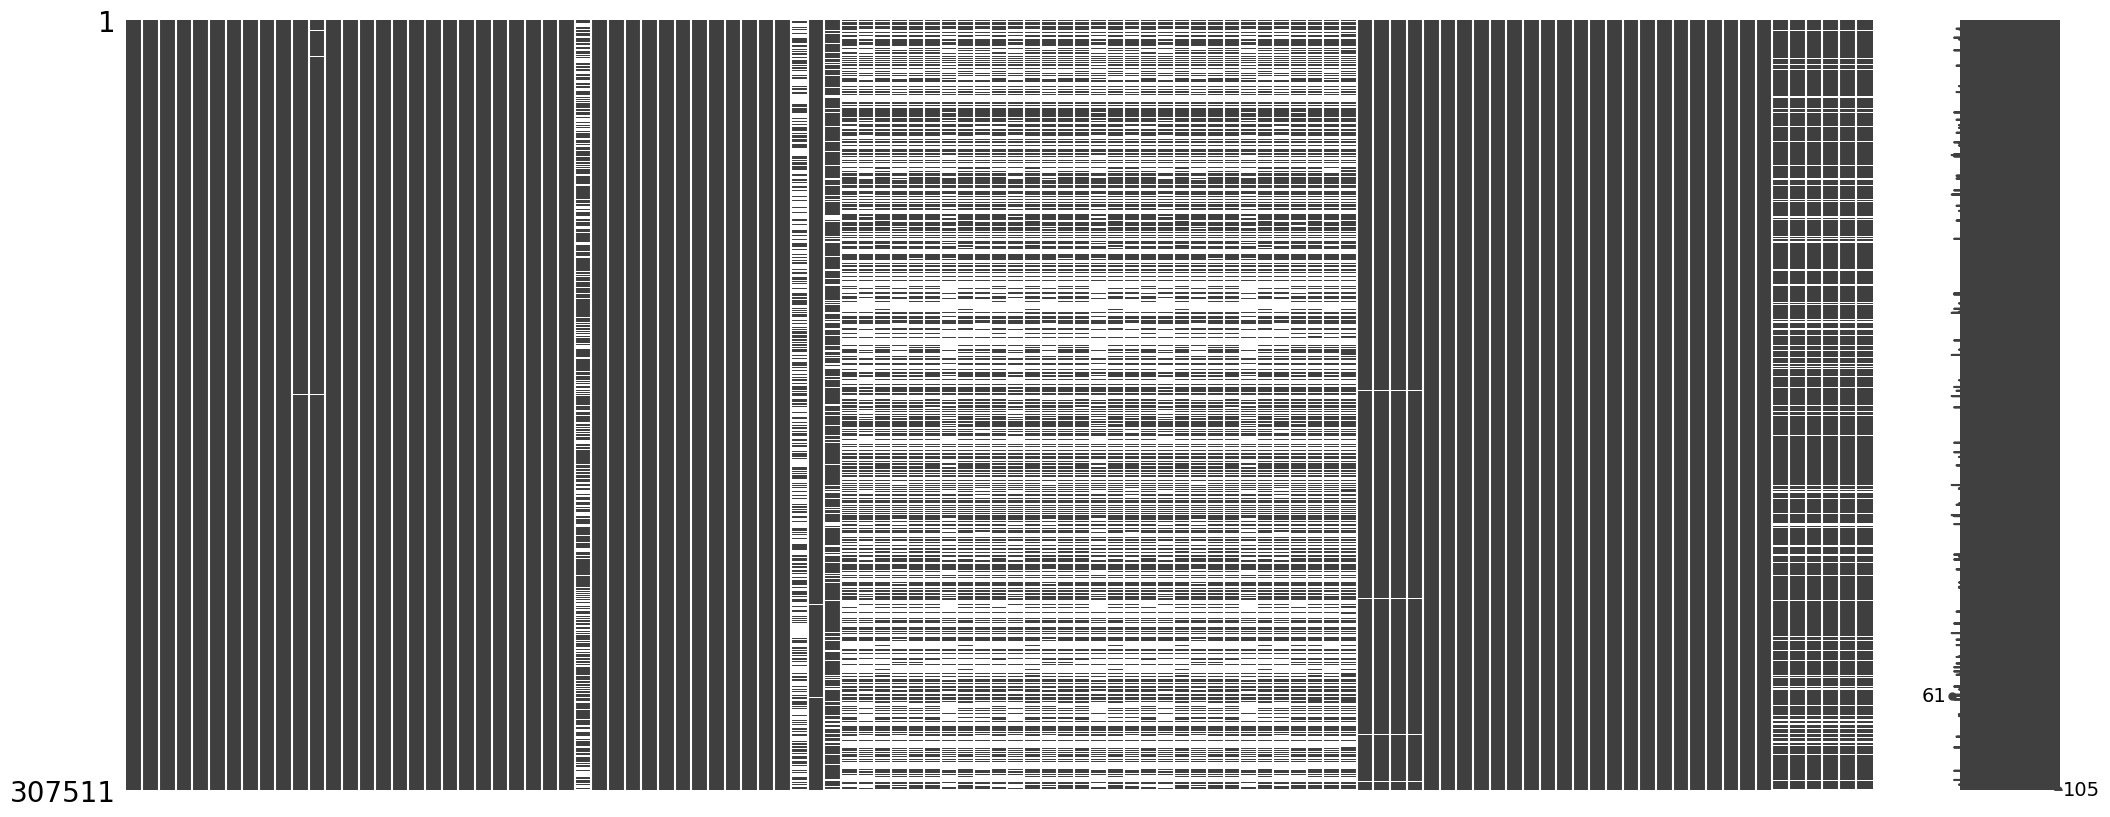